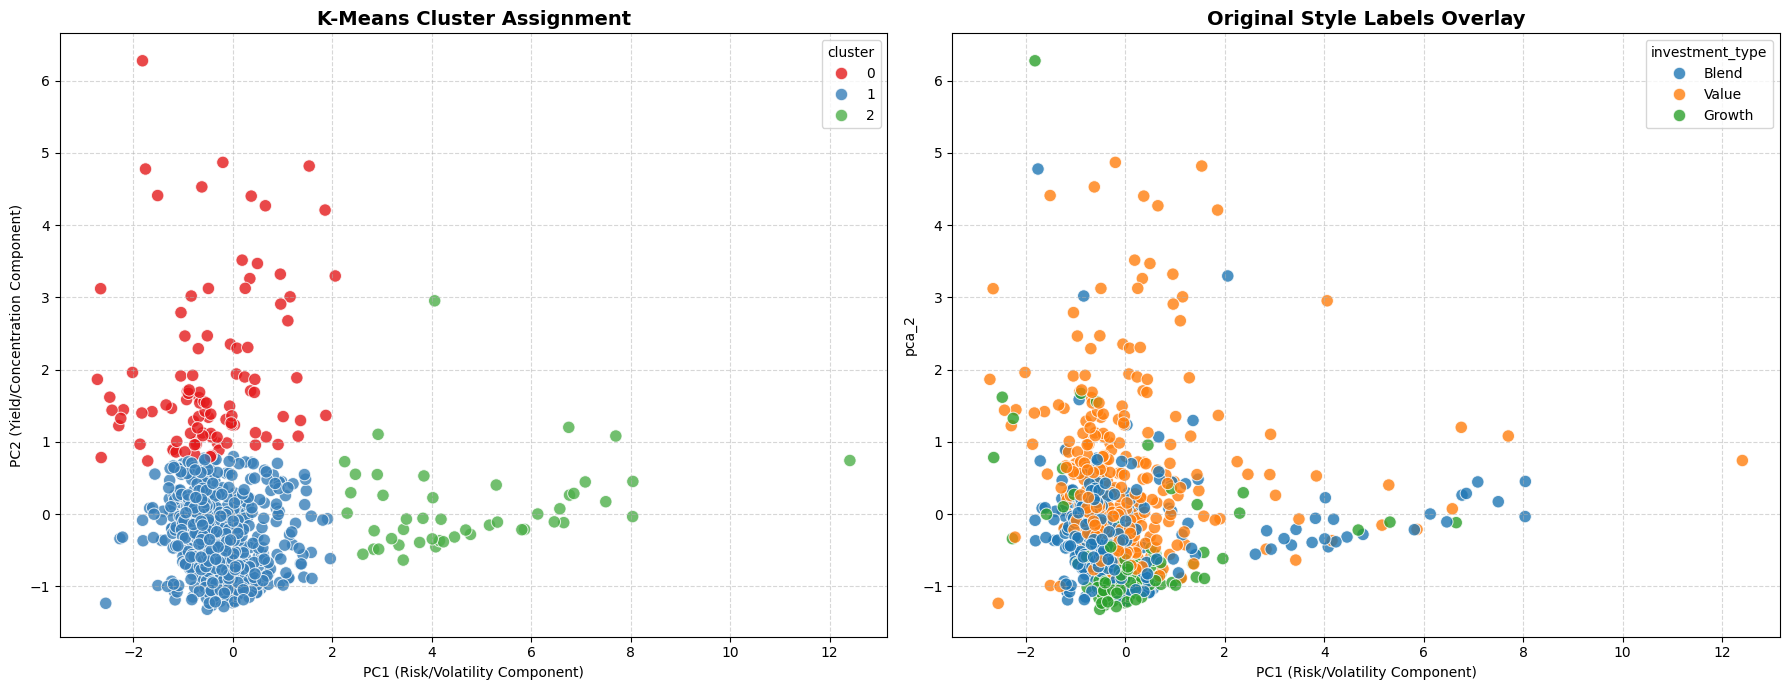

--- Cluster Profiles (Mean Values) ---
         fund_yield  top10_holdings_total_assets  fund_stdev_5years  \
cluster                                                               
0          0.048889                     0.374147          18.289798   
1          0.014429                     0.314174          17.612927   
2          0.007440                     1.047968          54.675532   

         fund_beta_5years  
cluster                    
0                1.122222  
1                1.035220  
2                2.755106  

--- Confusion Matrix (Cluster vs. Style) ---
investment_type  Blend  Growth  Value
cluster                              
0                    9       7     83
1                  286     111    218
2                   24       5     18


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv("/Users/hunglun/Library/Mobile Documents/com~apple~CloudDocs/Study/HKU_STAT/2025_Sem2/STAT8020/Project/8017Group4.1/data/ETF/METADATA/ETFs.csv")
# 1. Configuration
# Ensure your dataframe is named 'df' before running this
target_features = ["fund_yield", "top10_holdings_total_assets", "fund_stdev_5years", "fund_beta_5years"]
label_col = 'investment_type'

# 2. Data Cleaning
# We keep the label_col so we can compare the results later
data_subset = df[target_features + [label_col]].dropna().copy()

# 3. Preprocessing
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_subset[target_features])

# 4. Modeling: K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
data_subset['cluster'] = kmeans.fit_predict(X_scaled)

# 5. Dimensionality Reduction for Visualization
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(X_scaled)
data_subset['pca_1'] = pca_coords[:, 0]
data_subset['pca_2'] = pca_coords[:, 1]

# 6. Visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Subplot 1: The Clusters the Model Found
sns.scatterplot(
    ax=axes[0], data=data_subset, x='pca_1', y='pca_2', 
    hue='cluster', palette='Set1', s=80, alpha=0.8
)
axes[0].set_title('K-Means Cluster Assignment', fontsize=14, fontweight='bold')
axes[0].set_xlabel('PC1 (Risk/Volatility Component)')
axes[0].set_ylabel('PC2 (Yield/Concentration Component)')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Subplot 2: The Original "Investment Type" Labels
sns.scatterplot(
    ax=axes[1], data=data_subset, x='pca_1', y='pca_2', 
    hue=label_col, s=80, alpha=0.8
)
axes[1].set_title('Original Style Labels Overlay', fontsize=14, fontweight='bold')
axes[1].set_xlabel('PC1 (Risk/Volatility Component)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 7. Validation Output
print("--- Cluster Profiles (Mean Values) ---")
print(data_subset.groupby('cluster')[target_features].mean())

print("\n--- Confusion Matrix (Cluster vs. Style) ---")
confusion_matrix = pd.crosstab(data_subset['cluster'], data_subset[label_col])
print(confusion_matrix)